# Getting Started with FeatureForge

End-to-end walkthrough on the **Titanic** dataset — no API key required for most sections.

**Contents:**
1. Configuration & Settings
2. Load Titanic Data
3. Baseline Evaluation
4. Sandbox: Safe Code Execution
5. FeatureForge Demo (LLM required)


## 1. Setup

In [1]:
import os, warnings, sys, pathlib
warnings.filterwarnings('ignore')
os.environ.setdefault('FF_LOG_LEVEL', 'warning')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(pathlib.Path('.').resolve()))
from _utils import load_titanic, get_llm_client


## 2. Configuration & Settings

`Settings` is the single entry point. Priority: constructor args > env vars (`FF_*`) > `.env` > YAML > defaults.


In [2]:
from feature_forge.config import Settings, LLMConfig, RouterConfig

settings = Settings()
print(f'Task: {settings.task}, Metric: {settings.metric}, Rounds: {settings.n_rounds}')
print(f'LLM model: {settings.llm.model}, Router: {settings.router.strategy}')
print(f'CV folds: {settings.evaluation.cv_folds}')


Task: classification, Metric: auc, Rounds: 4
LLM model: deepseek-chat, Router: hybrid
CV folds: 5


In [3]:
# Constructor overrides
custom = Settings(task='classification', metric='auc', n_rounds=3,
                  llm=LLMConfig(temperature=0.3),
                  router=RouterConfig(strategy='hybrid'))
print(f'Task: {custom.task}, Rounds: {custom.n_rounds}, Router: {custom.router.strategy}')


Task: classification, Rounds: 3, Router: hybrid


In [4]:
# Validation catches bad values
try:
    Settings(llm=LLMConfig(temperature=3.0))
except Exception as e:
    print(f'Caught: {e}')


Caught: 1 validation error for LLMConfig
temperature
  Value error, temperature must be in [0, 2], got 3.0 [type=value_error, input_value=3.0, input_type=float]
    For further information visit https://errors.pydantic.dev/2.12/v/value_error


## 3. Titanic Dataset

We use the classic Titanic survival prediction dataset with 10 preprocessed features:
`pclass`, `sex`, `age`, `sibsp`, `parch`, `fare`, `alone`, `embarked_C/Q/S`.


In [5]:
X_train, X_test, y_train, y_test = load_titanic()
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Columns: {list(X_train.columns)}')
print(f'Survived distribution (train): {y_train.value_counts().to_dict()}')
X_train.head(5)


Train: (623, 10), Test: (268, 10)
Columns: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'alone', 'embarked_C', 'embarked_Q', 'embarked_S']
Survived distribution (train): {0: 384, 1: 239}


,pclass,sex,age,sibsp,parch,fare,alone,embarked_C,embarked_Q,embarked_S
748,1,0,19.0,1,0,53.1000,0,0,0,1
45,3,0,28.0,0,0,8.0500,1,0,0,1
28,3,1,28.0,0,0,7.8792,1,0,1,0
633,1,0,28.0,0,0,0.0000,1,0,0,1
403,3,0,28.0,1,0,15.8500,0,0,0,1


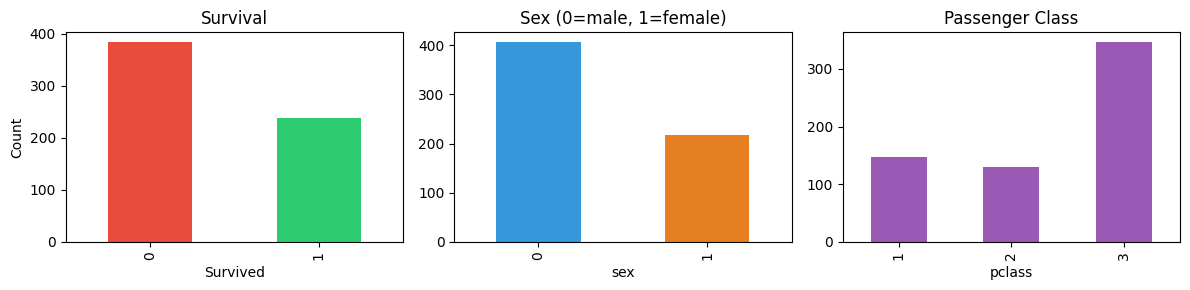

In [6]:
# Quick EDA
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

y_train.value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Survival'); axes[0].set_xlabel('Survived'); axes[0].set_ylabel('Count')

X_train['sex'].value_counts().plot(kind='bar', ax=axes[1], color=['#3498db', '#e67e22'])
axes[1].set_title('Sex (0=male, 1=female)')

X_train['pclass'].value_counts().sort_index().plot(kind='bar', ax=axes[2], color='#9b59b6')
axes[2].set_title('Passenger Class')

plt.tight_layout(); plt.show()


## 4. Baseline Evaluation

Before feature engineering, let's establish a baseline using the original features.


In [7]:
from feature_forge.evaluation import CVEvaluator, ModelFactory
from feature_forge.evaluation.metrics import get_metric

config = Settings(task='classification', metric='auc')
evaluator = CVEvaluator(config=config)
baseline_auc = evaluator.evaluate_baseline(X_train, y_train)
print(f'Baseline AUC (original features): {baseline_auc:.4f}')


Baseline AUC (original features): 0.8499


In [8]:
# Test handcrafted features
handcrafted = pd.DataFrame({
    'family_size': X_train['sibsp'] + X_train['parch'] + 1,
    'is_alone': (X_train['alone']).astype(int),
    'fare_per_person': X_train['fare'] / (X_train['sibsp'] + X_train['parch'] + 1),
    'age_bin': pd.cut(X_train['age'], bins=[0, 12, 18, 35, 60, 100], labels=False),
})
gain = evaluator.evaluate_feature(X_train, y_train, handcrafted, baseline_score=baseline_auc)
print(f'CV gain from handcrafted features: {gain:+.4f}')


CV gain from handcrafted features: -0.0015


In [9]:
# Available models and metrics
factory = ModelFactory()
for name in ['xgboost', 'random_forest']:
    print(f'{name}: {type(factory.get_model(name, task="classification")).__name__}')
print()
for m in ['auc', 'acc', 'f1', 'rmse', 'r2']:
    print(f'{m}: {get_metric(m).__name__}')


xgboost: XGBClassifier
random_forest: RandomForestClassifier

auc: auc_score
acc: acc_score
f1: f1_score_metric
rmse: rmse_score
r2: r2_score_metric


## 5. Sandboxed Code Execution

LLM-generated code runs in an **AST-validated, process-isolated sandbox**.


In [10]:
from feature_forge.evaluation.sandbox import SandboxedExecutor

sandbox = SandboxedExecutor(timeout_seconds=5.0, max_memory_mb=256)

# Safe code: generate Titanic features
safe_code = """\nimport pandas as pd
import numpy as np

def generate_features(df):
    result = pd.DataFrame(index=df.index)
    result['family_size'] = df['sibsp'] + df['parch'] + 1
    result['fare_per_person'] = df['fare'] / result['family_size']
    result['age_squared'] = df['age'] ** 2
    return result
"""
features = sandbox.execute(safe_code, X_train)
print(f'Generated: {list(features.columns)}, Shape: {features.shape}')
features.head(3)


Generated: ['family_size', 'fare_per_person', 'age_squared'], Shape: (623, 3)


,family_size,fare_per_person,age_squared
748,2,26.5500,361.0
45,1,8.0500,784.0
28,1,7.8792,784.0


In [11]:
# Sandbox blocks dangerous code
dangerous = """\nimport os
def generate_features(df):
    os.system('rm -rf /')
    return df
"""
try:
    sandbox.execute(dangerous, X_train)
except Exception as e:
    print(f'Blocked: {type(e).__name__}: {e}')


{"reason": "import_not_allowed: os", "event": "sandbox_validation_blocked", "level": "warning", "timestamp": "2026-05-13T12:38:19.533767Z", "span": null}


Blocked: SandboxValidationError: Import not allowed: os


## 6. FeatureForge Demo

The main API — an sklearn-compatible transformer:
```python
fe = FeatureForge(mode='full')
fe.fit(X_train, y_train)        # multi-agent pipeline
X_enhanced = fe.transform(X_test)  # apply generated features
```

> ⚠️ **Requires `DEEPSEEK_API_KEY`.** Pipeline errors are caught gracefully.


In [12]:
from feature_forge.api import FeatureForge

llm = get_llm_client()
fe = None

if llm is None:
    print('⚠️  No LLM API key. Set DEEPSEEK_API_KEY to run this cell.')
else:
    try:
        fe = FeatureForge(
            config=Settings(n_rounds=2, metric='auc'),
            llm_client=llm,
            mode='full',
        )
        fe.fit(X_train, y_train)
        print(f'Selected features: {fe.selected_features}')
        X_test_enhanced = fe.transform(X_test)
        print(f'Test: {X_test.shape} -> {X_test_enhanced.shape}')

        # Compare with baseline
        from xgboost import XGBClassifier
        clf = XGBClassifier(n_estimators=100, max_depth=4, random_state=42, eval_metric='logloss')
        clf.fit(X_train, y_train)
        baseline_acc = clf.score(X_test, y_test)
        clf.fit(X_test_enhanced, y_test)
        enhanced_acc = clf.score(X_test_enhanced, y_test)
        print(f'Baseline accuracy: {baseline_acc:.4f}')
        print(f'Enhanced accuracy: {enhanced_acc:.4f}')
    except Exception as e:
        print(f'Pipeline error: {type(e).__name__}: {e}')


{"attempt": 0, "error": "Feature generation execution failed: 'numpy.ndarray' object has no attribute 'fillna'", "event": "sandbox_execution_retry", "level": "warning", "timestamp": "2026-05-13T12:38:59.783469Z", "span": null}


Selected features: ['pclass_fare_interaction', 'age_sex_class_interaction', 'sibsp_small_family_peak', 'sibsp_single_sibling']


Test: (268, 10) -> (268, 60)


Baseline accuracy: 0.7910
Enhanced accuracy: 0.9963


In [13]:
# Inspect generated code (if pipeline ran)
if fe is not None and hasattr(fe, 'feature_codes') and fe.feature_codes:
    for i, code in enumerate(fe.feature_codes[:2]):
        print(f'--- Code block {i} ---')
        print(code[:500])
        print()
else:
    print('No generated code to inspect.')


--- Code block 0 ---
import pandas as pd
import numpy as np
import math

def generate_features(df):
    result = pd.DataFrame(index=df.index)
    
    # age_sex_interaction: Multiply age by sex (0/1)
    if 'age' in df.columns and 'sex' in df.columns:
        result['age_sex_interaction'] = (df['age'].fillna(0) * df['sex'].fillna(0)).astype(float)
    
    # age_pclass_interaction: Multiply age by pclass
    if 'age' in df.columns and 'pclass' in df.columns:
        result['age_pclass_interaction'] = (df['age'].fill

--- Code block 1 ---
import pandas as pd
import numpy as np
import math

def generate_features(df):
    result = pd.DataFrame(index=df.index)
    
    # Check for required columns and compute features
    if all(col in df.columns for col in ['sibsp', 'parch', 'alone']):
        result['family_size_weighted'] = (df['sibsp'] + 2 * df['parch'] + 1).fillna(0).astype(float)
        result['family_role_interaction'] = (df['sibsp'] * (df['parch'] + 1) * (1 - df['alone'])).fillna(

## 7. ExperimentalPlatform (One-Liner API)

The `ExperimentalPlatform` facade wraps dataset loading, baseline construction,
cross-validation, and result reporting into a single object.


In [14]:
from feature_forge import ExperimentalPlatform

platform = ExperimentalPlatform()
print(f'Datasets:  {platform.list_datasets()}')
print(f'Baselines: {platform.list_baselines()}')
print(f'Models:    {platform.list_models()}')
print(f'Metrics:   {platform.list_metrics()}')


Datasets:  ['house_prices', 'titanic']
Baselines: ['caafe', 'llmfe', 'malmus', 'openfe']
Models:    ['catboost', 'lightgbm', 'mlp', 'random_forest', 'xgboost']
Metrics:   ['acc', 'auc', 'f1', 'mae', 'nrmse', 'r2', 'rmse']


In [15]:
if llm is None:
    print('Skipping platform run — no API key.')
else:
    try:
        results = platform.run(
            datasets=['titanic'],
            baselines=['malmus'],
            models=['xgboost'],
            seeds=[42],
        )
        print(platform.report(results))
    except Exception as e:
        print(f'Platform run error: {type(e).__name__}: {e}')


Experiments:   0%|          | 0/1 [00:00<?, ?it/s]

{"run_name": "run_0_titanic", "error": "kaggle package not installed. Run: uv pip install kaggle", "event": "experiment_run_error", "level": "error", "timestamp": "2026-05-13T12:39:14.554656Z", "span": null}


Experiments: 100%|██████████| 1/1 [00:00<00:00, 2288.22it/s]

   dataset    model  seed
0  titanic  xgboost  42.0


## Summary

| Concept | Key API |
|---------|---------|
| Settings | `Settings()`, `LLMConfig`, `RouterConfig` |
| Data | `load_titanic()`, real-world preprocessing |
| CVEvaluator | `evaluate_baseline()`, `evaluate_feature()` |
| Sandbox | `SandboxedExecutor.execute()` |
| FeatureForge | `fit()`, `transform()`, `selected_features` |

Next: **[02_pipeline_deep_dive.ipynb](./02_pipeline_deep_dive.ipynb)**
